# Windowed decoding (exploratory)

Candidate figures for left-hemisphere windowed multivariate decoding.
Data: `../results/{task}(roi)(bipolar)/(decode){datatype}/` H5 outputs from
`run_decoding.py`.

Figures are displayed inline in the notebook only (no file export for now).

Style follows [`docs/PLOTTING_STYLE.md`](../docs/PLOTTING_STYLE.md).

In [1]:
%matplotlib inline

import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from mne_bids import BIDSPath
from IPython.display import display
from tqdm.auto import tqdm

In [2]:
cm = 1 / 2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'
mfg_color = '#666666'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

## Config

Edit `hue_order`, `hemi`, and `articulator_phoneme_filter` below.
`FIGURE_SPECS` lists task × decode-type combinations for batch export.

In [3]:
ref = 'bipolar'
phases = ['Stimulus', 'Delay', 'Go', 'Response']

hue_order = ['AIC', 'PIC', 'STG', 'SMC', 'MFG']
hemi = 'Left'
description = 'Repeat'
articulator_phoneme_filter = '1'
sig_p = 0.05

results_root = Path('..') / 'results'

# File export disabled for now — figures are shown inline only.
# export_dir = Path('../img/fig3')  # use when promoting to publication
# bars_dir = export_dir / 'windowed_bars'
# confusion_dir = export_dir / 'windowed_confusion'

FIGURE_SPECS = [
    ('LexicalDelay', 'lexicality'),
    ('LexicalDelay', 'lexicality', 'Decision'),
    ('LexicalDelay', 'phoneme'),
    ('LexicalDelay', 'articulator'),
    ('PhonemeSequence', 'phoneme'),
    ('PhonemeSequence', 'articulator'),
]

ROI_COLOR_MAP = {
    'AIC': red,
    'PIC': blue,
    'STG': stg_color,
    'SMC': smc_color,
    'MFG': mfg_color,
}

ARTICULATOR_CLASS_LABELS = ['dorsal', 'high', 'labial', 'low']


def parse_figure_spec(spec: tuple) -> tuple[str, str, str]:
    if len(spec) == 2:
        task, decode_type = spec
        return task, decode_type, description
    if len(spec) == 3:
        task, decode_type, spec_description = spec
        return task, decode_type, spec_description
    raise ValueError(f'Invalid FIGURE_SPECS entry: {spec!r}')


def roi_colors_for(rois: list[str]) -> list[str]:
    return [ROI_COLOR_MAP.get(roi, 'gray') for roi in rois]


def spec_suffix(spec_description: str) -> str:
    return '' if spec_description == 'Repeat' else f'_{spec_description}'


def bar_output_name(task: str, decode_type: str, spec_description: str, hemi_label: str) -> str:
    return f'{task}_{decode_type}{spec_suffix(spec_description)}_{hemi_label}.svg'


def confusion_output_name(
    task: str,
    decode_type: str,
    roi: str,
    phase: str,
    spec_description: str,
) -> str:
    return f'{task}_{decode_type}_{roi}_{phase}{spec_suffix(spec_description)}.svg'

## Load windowed decoding results

`load_windowed_decoding()` reads `(decode){datatype}` H5 files and returns a long
DataFrame (one row per fold). Summary columns (`accuracy_stable`, `p_value`,
`n_classes`, `h5_path`) are repeated on each fold row.

In [4]:
N_CLASSES = {
    ('phoneme', 'LexicalDelay'): 5,
    ('phoneme', 'PhonemeSequence'): 5,
    ('articulator', 'LexicalDelay'): 4,
    ('articulator', 'PhonemeSequence'): 4,
    ('lexicality', 'LexicalDelay'): 2,
}
_DECODE_TYPE_DEFAULT_N = {
    'phoneme': 5,
    'articulator': 4,
    'lexicality': 2,
}

WINDOW_SCORE_COLUMNS = [
    'fold', 'accuracy', 'accuracy_stable', 'p_value', 'n_classes',
    'roi', 'phase', 'hemi', 'description', 'phoneme', 'datatype', 'h5_path',
]


def chance_level(decode_type: str, task: str, n_classes: int | None = None) -> float:
    """Chance accuracy = 1 / n_classes."""
    if n_classes is not None:
        return 1.0 / n_classes
    n = N_CLASSES.get((decode_type, task))
    if n is None:
        n = _DECODE_TYPE_DEFAULT_N.get(decode_type)
    if n is None:
        warnings.warn(f'Unknown decode_type={decode_type!r}; using n_classes=2')
        n = 2
    return 1.0 / n


def _empty_window_scores() -> pd.DataFrame:
    return pd.DataFrame(columns=WINDOW_SCORE_COLUMNS)


def _h5_window_to_long_df(path) -> pd.DataFrame:
    with h5py.File(path, 'r') as mat:
        accuracy = np.asarray(mat['accuracy'][()], dtype=float)
        accuracy_stable = float(mat['accuracy_stable'][()])
        p_value = float(mat['p_value'][()])
        classes = np.asarray(mat['classes'][()])

    n_folds = accuracy.shape[0]
    n_classes = len(classes)
    hemi_label = 'Left' if path.subject.endswith('l') else 'Right'

    df = pd.DataFrame({
        'fold': np.arange(n_folds),
        'accuracy': accuracy,
        'accuracy_stable': accuracy_stable,
        'p_value': p_value,
        'n_classes': n_classes,
        'roi': path.subject[:-1],
        'phase': path.processing,
        'hemi': hemi_label,
        'description': path.description,
        'phoneme': path.recording,
        'datatype': path.datatype.replace('(decode)', ''),
        'h5_path': str(path),
    })
    return df


def load_windowed_decoding(
    task: str,
    decode_type: str,
    *,
    ref: str = 'bipolar',
    rois=None,
    hemi: str | None = None,
    description: str | None = None,
    articulator_phoneme_filter: str | None = '1',
    results_root=Path('..') / 'results',
) -> pd.DataFrame:
    """Load windowed decoding scores from `(decode){datatype}` H5 outputs."""
    results_root = Path(results_root)
    root = results_root / f'{task}(roi)({ref})'
    if not root.exists():
        warnings.warn(f'Missing decoding results directory: {root}')
        return _empty_window_scores()

    result_path = BIDSPath(
        datatype=f'(decode){decode_type}',
        root=str(root),
        suffix='highgamma',
        check=False,
    )
    paths = result_path.match()
    if not paths:
        warnings.warn(
            f'No windowed decoding H5 files for task={task}, decode_type={decode_type}'
        )
        return _empty_window_scores()

    frames = []
    for path in paths:
        try:
            frames.append(_h5_window_to_long_df(path))
        except OSError as exc:
            warnings.warn(f'Skipping unreadable file {path}: {exc}')

    if not frames:
        return _empty_window_scores()

    scores = pd.concat(frames, ignore_index=True)

    if description is not None:
        scores = scores[scores['description'] == description]
    if hemi is not None:
        scores = scores[scores['hemi'] == hemi]
    if rois is not None:
        scores = scores[scores['roi'].isin(rois)]
    if decode_type == 'articulator' and articulator_phoneme_filter is not None:
        scores = scores[scores['phoneme'] == articulator_phoneme_filter]

    return scores.reset_index(drop=True)


def window_summary(scores: pd.DataFrame) -> pd.DataFrame:
    """One row per (roi, phase) with stable accuracy and significance."""
    if scores.empty:
        return pd.DataFrame()
    return (
        scores.groupby(['roi', 'phase'], as_index=False)
        .agg(
            accuracy_stable=('accuracy_stable', 'first'),
            p_value=('p_value', 'first'),
            n_classes=('n_classes', 'first'),
            h5_path=('h5_path', 'first'),
        )
    )

## Plotting functions

- `plot_window_accuracy_overview` — 1×4 bar panels with chance dashed line and `*` for `p < 0.05`
- `plot_confusion_matrix` — normalized confusion heatmap from a single H5 path

In [ ]:
def _style_axes(ax, *, hide_left: bool = False) -> None:
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)
    if hide_left:
        ax.set_yticklabels([])
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)


def _overview_ylim(scores: pd.DataFrame, chance: float, pad: float = 0.08) -> tuple[float, float]:
    vals = scores['accuracy'].dropna()
    if vals.empty:
        return 0.0, max(chance * 2, 0.5)
    ymin = max(0.0, float(vals.min()) - pad)
    ymax = max(float(vals.max()) + pad, chance + pad)
    return ymin, ymax


def _add_significance_stars(ax, subset: pd.DataFrame, roi_order: list[str], y_top: float) -> None:
    summary = window_summary(subset)
    if summary.empty:
        return
    sig = summary[summary['p_value'] < sig_p].set_index('roi')
    # With hue=roi, seaborn creates one patch per ROI in order.
    patches = [p for p in ax.patches if p.get_height() > 0 or p.get_width() > 0]
    if len(patches) < len(roi_order):
        patches = list(ax.patches)[:len(roi_order)]
    for i, roi in enumerate(roi_order):
        if roi not in sig.index or i >= len(patches):
            continue
        patch = patches[i]
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height() + patch.get_y() + 0.01
        ax.text(x, min(y, y_top - 0.01), '*', ha='center', va='bottom', fontsize=fontsize)


def plot_window_accuracy_overview(
    scores: pd.DataFrame,
    *,
    phases: list[str],
    roi_order: list[str],
    hemi_label: str,
    chance: float,
    title: str | None = None,
) -> plt.Figure:
    if scores.empty:
        raise ValueError('No decoding scores to plot.')

    present_rois = [r for r in roi_order if r in set(scores['roi'])]
    if not present_rois:
        raise ValueError('No ROI matches in scores for the requested hue_order.')

    ymin, ymax = _overview_ylim(scores, chance)

    fig, axes = plt.subplots(1, len(phases), figsize=(3.0 * len(phases) * cm, 4.0 * cm))
    if len(phases) == 1:
        axes = [axes]
    fig.subplots_adjust(wspace=0.35, bottom=0.32)

    for j, phase in enumerate(phases):
        ax = axes[j]
        subset = scores[(scores['phase'] == phase) & (scores['hemi'] == hemi_label)]
        phase_rois = [r for r in present_rois if r in set(subset['roi'])]
        phase_palette = roi_colors_for(phase_rois)

        if phase_rois:
            sns.barplot(
                data=subset,
                x='roi',
                y='accuracy',
                hue='roi',
                order=phase_rois,
                hue_order=phase_rois,
                palette=phase_palette,
                legend=False,
                ax=ax,
                errorbar='se',
                capsize=0.08,
                err_kws={'linewidth': 0.75},
                linewidth=0,
            )
            _add_significance_stars(ax, subset, phase_rois, ymax)

        ax.axhline(y=chance, color='gray', linestyle='--', lw=0.5)
        ax.set_ylim(ymin, ymax)
        ax.set_title(phase, fontsize=fontsize)
        ax.set_xlabel('')
        if j == 0:
            ax.set_ylabel('Accuracy', fontsize=fontsize)
        else:
            ax.set_ylabel('')
        _style_axes(ax, hide_left=(j != 0))
        # Apply after despine/tick_params so rotation is not overwritten.
        ax.tick_params(axis='x', rotation=90, labelsize=fontsize)
        if phase_rois:
            ax.set_xticks(range(len(phase_rois)))
            ax.set_xticklabels(
                phase_rois, rotation=90, ha='center', va='top', fontsize=fontsize,
            )

    if title:
        fig.suptitle(title, fontsize=fontsize, y=1.02)
    return fig


def class_tick_labels(classes: np.ndarray, decode_type: str) -> list[str]:
    classes = np.asarray(classes)
    if decode_type == 'articulator' and len(classes) == len(ARTICULATOR_CLASS_LABELS):
        return ARTICULATOR_CLASS_LABELS
    if decode_type == 'lexicality' and len(classes) == 2:
        return ['class0', 'class1']
    return [str(int(c)) for c in classes]


def load_confusion_from_h5(h5_path: str | Path) -> tuple[np.ndarray, list[str]]:
    with h5py.File(h5_path, 'r') as mat:
        conf = np.asarray(mat['confusion_norm'][()], dtype=float)
        classes = np.asarray(mat['classes'][()])
    return conf, [str(int(c)) for c in classes]


def plot_confusion_matrix(
    h5_path: str | Path,
    *,
    decode_type: str,
    title: str | None = None,
    cmap=reds,
) -> plt.Figure | None:
    h5_path = Path(h5_path)
    if not h5_path.exists():
        warnings.warn(f'Missing H5 for confusion matrix: {h5_path}')
        return None

    with h5py.File(h5_path, 'r') as mat:
        conf = np.asarray(mat['confusion_norm'][()], dtype=float)
        classes = np.asarray(mat['classes'][()])

    labels = class_tick_labels(classes, decode_type)
    n_classes = len(labels)
    chance = 1.0 / n_classes
    vmax = min(1.0, max(0.4, chance * 2.5))

    fig, ax = plt.subplots(figsize=(3.5 * cm, 3 * cm))
    sns.heatmap(
        conf,
        annot=True,
        fmt='.2f',
        cmap=cmap,
        annot_kws={'size': fontsize},
        cbar=True,
        vmin=0.0,
        vmax=vmax,
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_xlabel('Predicted', fontsize=fontsize)
    ax.set_ylabel('True', fontsize=fontsize)
    if title:
        ax.set_title(title, fontsize=fontsize)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=0.75)
    return fig

## Preview

Preview PhonemeSequence/phoneme (Repeat): 80 fold rows | ROIs: ['AIC', 'MFG', 'PIC', 'SMC', 'STG'] | chance=0.111


,fold,accuracy,accuracy_stable,p_value,n_classes,roi,phase,hemi,description,phoneme,datatype,h5_path
0,0,0.074074,0.15358,0.00995,9,AIC,Delay,Left,Repeat,1,phoneme,../results/PhonemeSequence(roi)(bipolar)/sub-A...
1,1,0.148148,0.15358,0.00995,9,AIC,Delay,Left,Repeat,1,phoneme,../results/PhonemeSequence(roi)(bipolar)/sub-A...
2,2,0.305556,0.15358,0.00995,9,AIC,Delay,Left,Repeat,1,phoneme,../results/PhonemeSequence(roi)(bipolar)/sub-A...
3,3,0.148148,0.15358,0.00995,9,AIC,Delay,Left,Repeat,1,phoneme,../results/PhonemeSequence(roi)(bipolar)/sub-A...
4,4,0.203704,0.15358,0.00995,9,AIC,Delay,Left,Repeat,1,phoneme,../results/PhonemeSequence(roi)(bipolar)/sub-A...


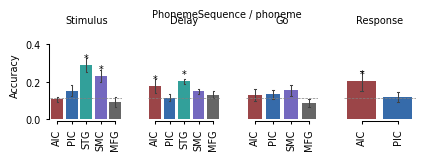

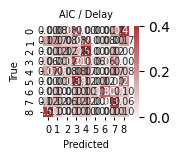

In [8]:
preview_task, preview_decode, preview_description = parse_figure_spec(FIGURE_SPECS[-2])
preview_scores = load_windowed_decoding(
    preview_task,
    preview_decode,
    ref=ref,
    rois=hue_order,
    hemi=hemi,
    description=preview_description,
    articulator_phoneme_filter=articulator_phoneme_filter,
    results_root=results_root,
)

if preview_scores.empty:
    print('No preview data loaded.')
else:
    preview_n_classes = int(preview_scores['n_classes'].iloc[0])
    preview_chance = chance_level(preview_decode, preview_task, n_classes=preview_n_classes)
    print(
        f'Preview {preview_task}/{preview_decode} ({preview_description}): '
        f'{len(preview_scores):,} fold rows | '
        f"ROIs: {sorted(preview_scores['roi'].unique())} | "
        f'chance={preview_chance:.3f}'
    )
    display(preview_scores.head())

    fig = plot_window_accuracy_overview(
        preview_scores,
        phases=phases,
        roi_order=hue_order,
        hemi_label=hemi,
        chance=preview_chance,
        title=f'{preview_task} / {preview_decode}',
    )
    plt.show()

    preview_summary = window_summary(preview_scores)
    if not preview_summary.empty:
        sample = preview_summary.iloc[0]
        fig_cm = plot_confusion_matrix(
            sample['h5_path'],
            decode_type=preview_decode,
            title=f"{sample['roi']} / {sample['phase']}",
        )
        if fig_cm is not None:
            plt.show()

## Batch preview (inline)

Loops over `FIGURE_SPECS` and displays figures in the notebook. File export is commented out below.

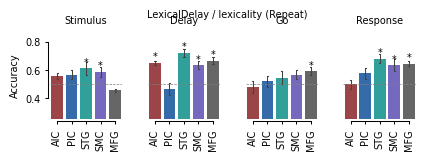

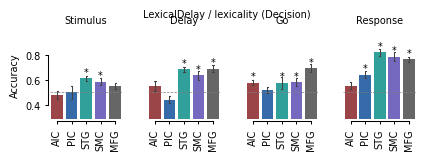

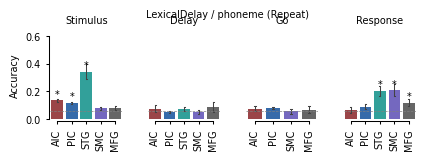

/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_345892/1104357342.py:14: UserWarning: Skipping (no data): LexicalDelay / articulator / Repeat
  warnings.warn(f'Skipping (no data): {task} / {decode_type} / {spec_description}')


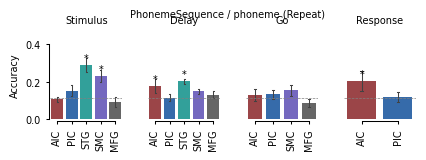

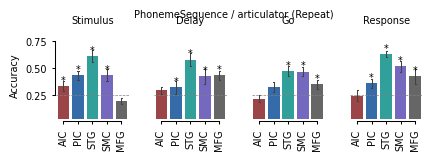

In [7]:
for spec in FIGURE_SPECS:
    task, decode_type, spec_description = parse_figure_spec(spec)
    scores = load_windowed_decoding(
        task,
        decode_type,
        ref=ref,
        rois=hue_order,
        hemi=hemi,
        description=spec_description,
        articulator_phoneme_filter=articulator_phoneme_filter,
        results_root=results_root,
    )
    if scores.empty:
        warnings.warn(f'Skipping (no data): {task} / {decode_type} / {spec_description}')
        continue

    n_classes = int(scores['n_classes'].mode().iloc[0])
    chance = chance_level(decode_type, task, n_classes=n_classes)

    fig = plot_window_accuracy_overview(
        scores,
        phases=phases,
        roi_order=hue_order,
        hemi_label=hemi,
        chance=chance,
        title=f'{task} / {decode_type} ({spec_description})',
    )
    plt.show()

    # --- file export (disabled) ---
    # bars_dir.mkdir(parents=True, exist_ok=True)
    # bar_path = bars_dir / bar_output_name(task, decode_type, spec_description, hemi)
    # fig.savefig(bar_path, dpi=300, bbox_inches='tight')

    # Confusion matrices: use the Preview cell, or re-enable export below.
    # summary = window_summary(scores)
    # for _, row in summary.iterrows():
    #     ...